In [989]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [990]:
# basic analysis

def basic_analysis(data):
    print(f"Data shape: {data.shape}\n")
    print(f"Columns: \n{data.columns}\n")
    print(f"Misisng values: \n{data.isnull().sum()} \n")

In [991]:
df = pd.read_csv("../data/raw/bookings.csv")
print("Raw bookings dataset basic analysis: \n")
basic_analysis(df)
df.head()

Raw bookings dataset basic analysis: 

Data shape: (3178, 26)

Columns: 
Index(['key_id', 'booking_id', 'tournament_id', 'tournament_name', 'match_id',
       'match_name', 'match_date', 'stage_name', 'group_name', 'team_id',
       'team_name', 'team_code', 'home_team', 'away_team', 'player_id',
       'family_name', 'given_name', 'shirt_number', 'minute_label',
       'minute_regulation', 'minute_stoppage', 'match_period', 'yellow_card',
       'red_card', 'second_yellow_card', 'sending_off'],
      dtype='object')

Misisng values: 
key_id                0
booking_id            0
tournament_id         0
tournament_name       0
match_id              0
match_name            0
match_date            0
stage_name            0
group_name            0
team_id               0
team_name             0
team_code             0
home_team             0
away_team             0
player_id             0
family_name           0
given_name            0
shirt_number          0
minute_label          0
min

,key_id,booking_id,tournament_id,tournament_name,match_id,match_name,match_date,stage_name,group_name,team_id,...,given_name,shirt_number,minute_label,minute_regulation,minute_stoppage,match_period,yellow_card,red_card,second_yellow_card,sending_off
0,1,B-0001,WC-1970,1970 FIFA Men's World Cup,M-1970-01,Mexico vs Soviet Union,1970-05-31,group stage,Group 1,T-72,...,Kakhi,11,30',30,0,first half,1,0,0,0
1,2,B-0002,WC-1970,1970 FIFA Men's World Cup,M-1970-01,Mexico vs Soviet Union,1970-05-31,group stage,Group 1,T-72,...,Givi,19,31',31,0,first half,1,0,0,0
2,3,B-0003,WC-1970,1970 FIFA Men's World Cup,M-1970-01,Mexico vs Soviet Union,1970-05-31,group stage,Group 1,T-72,...,Evgeny,6,34',34,0,first half,1,0,0,0
3,4,B-0004,WC-1970,1970 FIFA Men's World Cup,M-1970-01,Mexico vs Soviet Union,1970-05-31,group stage,Group 1,T-46,...,Gustavo,3,60',60,0,second half,1,0,0,0
4,5,B-0005,WC-1970,1970 FIFA Men's World Cup,M-1970-01,Mexico vs Soviet Union,1970-05-31,group stage,Group 1,T-72,...,Gennady,7,72',72,0,second half,1,0,0,0


In [992]:
# This work focuses on FIFA Men's World Cup only

df = df[df["tournament_name"].str.contains("Men's")]
print(f"Current data shape: {df.shape}")

Current data shape: (2624, 26)


In [993]:
# drop ununsed/irrelevant columns

df = df.drop(columns = ["key_id", "tournament_name", "group_name", "team_code", 
                        "shirt_number", "family_name", "given_name", "minute_regulation", "home_team", 
                        "away_team", "minute_label", "minute_stoppage", "match_period", "sending_off"])
print(f"Current data shape: {df.shape} \n")
print(f"Columns: {df.columns}")
df.head()

Current data shape: (2624, 12) 

Columns: Index(['booking_id', 'tournament_id', 'match_id', 'match_name', 'match_date',
       'stage_name', 'team_id', 'team_name', 'player_id', 'yellow_card',
       'red_card', 'second_yellow_card'],
      dtype='object')


,booking_id,tournament_id,match_id,match_name,match_date,stage_name,team_id,team_name,player_id,yellow_card,red_card,second_yellow_card
0,B-0001,WC-1970,M-1970-01,Mexico vs Soviet Union,1970-05-31,group stage,T-72,Soviet Union,P-33189,1,0,0
1,B-0002,WC-1970,M-1970-01,Mexico vs Soviet Union,1970-05-31,group stage,T-72,Soviet Union,P-43733,1,0,0
2,B-0003,WC-1970,M-1970-01,Mexico vs Soviet Union,1970-05-31,group stage,T-72,Soviet Union,P-52906,1,0,0
3,B-0004,WC-1970,M-1970-01,Mexico vs Soviet Union,1970-05-31,group stage,T-46,Mexico,P-64553,1,0,0
4,B-0005,WC-1970,M-1970-01,Mexico vs Soviet Union,1970-05-31,group stage,T-72,Soviet Union,P-70408,1,0,0


In [994]:
# load the team dataset - confederation lookup 

df_teams = pd.read_csv("../data/raw/teams.csv")
df_teams = df_teams[["team_id", "team_name", "confederation_code"]]
df_teams = df_teams[["team_id", "confederation_code"]]
df_teams.head()

,team_id,confederation_code
0,T-01,CAF
1,T-02,CAF
2,T-03,CONMEBOL
3,T-04,AFC
4,T-05,UEFA


In [995]:
# referee dataset - referee confederation lookup

df_ref = pd.read_csv("../data/processed/referee.csv")
df_ref = df_ref[["match_id", "referee_id", "confederation_code"]]
df_ref = df_ref.rename(columns = {"confederation_code": "ref_confederation"})
df_ref.head()

,match_id,referee_id,ref_confederation
0,M-1970-01,R-440,UEFA
1,M-1970-02,R-115,UEFA
2,M-1970-03,R-254,UEFA
3,M-1970-04,R-392,UEFA
4,M-1970-05,R-358,UEFA


In [996]:
# merge bookings with referee data

df = pd.merge(
    df, 
    df_ref, 
    on = "match_id", 
    how = "left"
).merge(
    df_teams.rename(columns = {"confederation_code": "team_confederation"}), 
    on = "team_id",
    how = "left"
)

desired_order = ['booking_id', 'tournament_id', 'match_id', 'match_name', 'match_date',
                'stage_name', 'team_id', 'team_name','team_confederation', 'player_id',
                'yellow_card', 'red_card', 'second_yellow_card', 'referee_id', 'ref_confederation']
df = df.reindex(columns = desired_order)

print(f"Current data shape: {df.shape} \n")
print(f"Columns: {df.columns}")
df.head()

Current data shape: (2624, 15) 

Columns: Index(['booking_id', 'tournament_id', 'match_id', 'match_name', 'match_date',
       'stage_name', 'team_id', 'team_name', 'team_confederation', 'player_id',
       'yellow_card', 'red_card', 'second_yellow_card', 'referee_id',
       'ref_confederation'],
      dtype='object')


,booking_id,tournament_id,match_id,match_name,match_date,stage_name,team_id,team_name,team_confederation,player_id,yellow_card,red_card,second_yellow_card,referee_id,ref_confederation
0,B-0001,WC-1970,M-1970-01,Mexico vs Soviet Union,1970-05-31,group stage,T-72,Soviet Union,UEFA,P-33189,1,0,0,R-440,UEFA
1,B-0002,WC-1970,M-1970-01,Mexico vs Soviet Union,1970-05-31,group stage,T-72,Soviet Union,UEFA,P-43733,1,0,0,R-440,UEFA
2,B-0003,WC-1970,M-1970-01,Mexico vs Soviet Union,1970-05-31,group stage,T-72,Soviet Union,UEFA,P-52906,1,0,0,R-440,UEFA
3,B-0004,WC-1970,M-1970-01,Mexico vs Soviet Union,1970-05-31,group stage,T-46,Mexico,CONCACAF,P-64553,1,0,0,R-440,UEFA
4,B-0005,WC-1970,M-1970-01,Mexico vs Soviet Union,1970-05-31,group stage,T-72,Soviet Union,UEFA,P-70408,1,0,0,R-440,UEFA


In [997]:
df.groupby(["yellow_card", "red_card", "second_yellow_card"]).size().reset_index()

,yellow_card,red_card,second_yellow_card,0
0,0,1,0,76
1,1,0,0,2470
2,1,0,1,62
3,1,1,0,16


In [998]:
def reset_yellow(row):
    if row["red_card"] == 1:
        return 0
    else:
        return 1

In [999]:
df["yellow_card"] = df.apply(reset_yellow, axis = 1)
print("After fixing yellow + red cards combo:")
print(f"{df.groupby(["yellow_card", "red_card", "second_yellow_card"]).size().reset_index()} \n")

df["yellow_card"] = df["yellow_card"] + df["second_yellow_card"]
print("After adding up second yellow cards:")
print(f"{df.groupby(["yellow_card", "red_card", "second_yellow_card"]).size().reset_index()} \n")

df = df.drop(columns = "second_yellow_card")
print("After dropping second_yellow_card:")
print(df.groupby(["yellow_card", "red_card"]).size().reset_index())

After fixing yellow + red cards combo:
   yellow_card  red_card  second_yellow_card     0
0            0         1                   0    92
1            1         0                   0  2470
2            1         0                   1    62 

After adding up second yellow cards:
   yellow_card  red_card  second_yellow_card     0
0            0         1                   0    92
1            1         0                   0  2470
2            2         0                   1    62 

After dropping second_yellow_card:
   yellow_card  red_card     0
0            0         1    92
1            1         0  2470
2            2         0    62


In [1000]:
# yellow cards by team-match

df_team_match_booking = df.groupby(['match_id', 'ref_confederation', 'team_confederation', 'team_id'])['yellow_card'].sum().reset_index()
basic_analysis(df_team_match_booking)
df_team_match_booking.head()

Data shape: (1224, 5)

Columns: 
Index(['match_id', 'ref_confederation', 'team_confederation', 'team_id',
       'yellow_card'],
      dtype='object')

Misisng values: 
match_id              0
ref_confederation     0
team_confederation    0
team_id               0
yellow_card           0
dtype: int64 



,match_id,ref_confederation,team_confederation,team_id,yellow_card
0,M-1970-01,UEFA,CONCACAF,T-46,1
1,M-1970-01,UEFA,UEFA,T-72,4
2,M-1970-06,UEFA,UEFA,T-74,1
3,M-1970-07,CONMEBOL,CONMEBOL,T-09,1
4,M-1970-11,CONCACAF,UEFA,T-21,1


Yellow cards are used exclusively in this work as they better capture discretionary referee judgment, the mechanism through which confederation bias would most plausibly operate.

In [1001]:
# average number of yellow cards given to teams from each conf by refs from each conf
# drop OFC because of exceptionally low presence

df_ref_team_match = pd.crosstab(
    index = df_team_match_booking["ref_confederation"],
    columns = df_team_match_booking["team_confederation"],
    values = df_team_match_booking["yellow_card"],
    aggfunc = "mean"
)
df_ref_team_match = df_ref_team_match.fillna(0)
df_ref_team_match = df_ref_team_match.reset_index()
print(df_ref_team_match)
df_ref_team_match = df_ref_team_match[df_ref_team_match["ref_confederation"] != "OFC"]
df_ref_team_match = df_ref_team_match.drop(columns = "OFC")
df_ref_team_match.columns = ["ref_confederation", "AFC", "CAF", "CONCACAF", "CONMEBOL", "UEFA"]
df_ref_team_match

team_confederation ref_confederation       AFC       CAF  CONCACAF  CONMEBOL  \
0                                AFC  1.750000  2.500000  2.846154  2.360000   
1                                CAF  2.000000  0.000000  2.000000  1.956522   
2                           CONCACAF  2.272727  2.055556  1.000000  1.837838   
3                           CONMEBOL  2.296296  2.063830  2.217391  1.833333   
4                                OFC  0.000000  1.000000  0.000000  0.000000   
5                               UEFA  2.339286  2.277778  2.395349  2.193798   

team_confederation  OFC      UEFA  
0                   1.0  2.142857  
1                   2.0  2.230769  
2                   3.0  1.971429  
3                   0.0  2.000000  
4                   0.0  1.000000  
5                   0.0  2.020478  


,ref_confederation,AFC,CAF,CONCACAF,CONMEBOL,UEFA
0,AFC,1.750000,2.500000,2.846154,2.360000,2.142857
1,CAF,2.000000,0.000000,2.000000,1.956522,2.230769
2,CONCACAF,2.272727,2.055556,1.000000,1.837838,1.971429
3,CONMEBOL,2.296296,2.063830,2.217391,1.833333,2.000000
5,UEFA,2.339286,2.277778,2.395349,2.193798,2.020478


In [1002]:
# count number of matches played by teams from each confederation officated by refs from each confederation

df_match_count = pd.crosstab(
    index = df_team_match_booking["ref_confederation"],
    columns = df_team_match_booking["team_confederation"],
    values = df_team_match_booking["yellow_card"],
    aggfunc = "count"
)
df_match_count = df_match_count.fillna(0)
df_match_count = df_match_count.reset_index()
print(df_match_count)
df_match_count = df_match_count[df_match_count["ref_confederation"] != "OFC"]
df_match_count = df_match_count.drop(columns = "OFC")
df_match_count.columns = ["ref_confederation", "AFC", "CAF", "CONCACAF", "CONMEBOL", "UEFA"]
df_match_count

team_confederation ref_confederation   AFC   CAF  CONCACAF  CONMEBOL  OFC  \
0                                AFC   8.0  24.0      26.0      25.0  1.0   
1                                CAF  13.0   0.0      13.0      23.0  1.0   
2                           CONCACAF  11.0  18.0       1.0      37.0  1.0   
3                           CONMEBOL  27.0  47.0      23.0       6.0  0.0   
4                                OFC   0.0   3.0       0.0       0.0  0.0   
5                               UEFA  56.0  54.0      43.0     129.0  0.0   

team_confederation   UEFA  
0                    70.0  
1                    39.0  
2                    70.0  
3                   160.0  
4                     2.0  
5                   293.0  


,ref_confederation,AFC,CAF,CONCACAF,CONMEBOL,UEFA
0,AFC,8.0,24.0,26.0,25.0,70.0
1,CAF,13.0,0.0,13.0,23.0,39.0
2,CONCACAF,11.0,18.0,1.0,37.0,70.0
3,CONMEBOL,27.0,47.0,23.0,6.0,160.0
5,UEFA,56.0,54.0,43.0,129.0,293.0


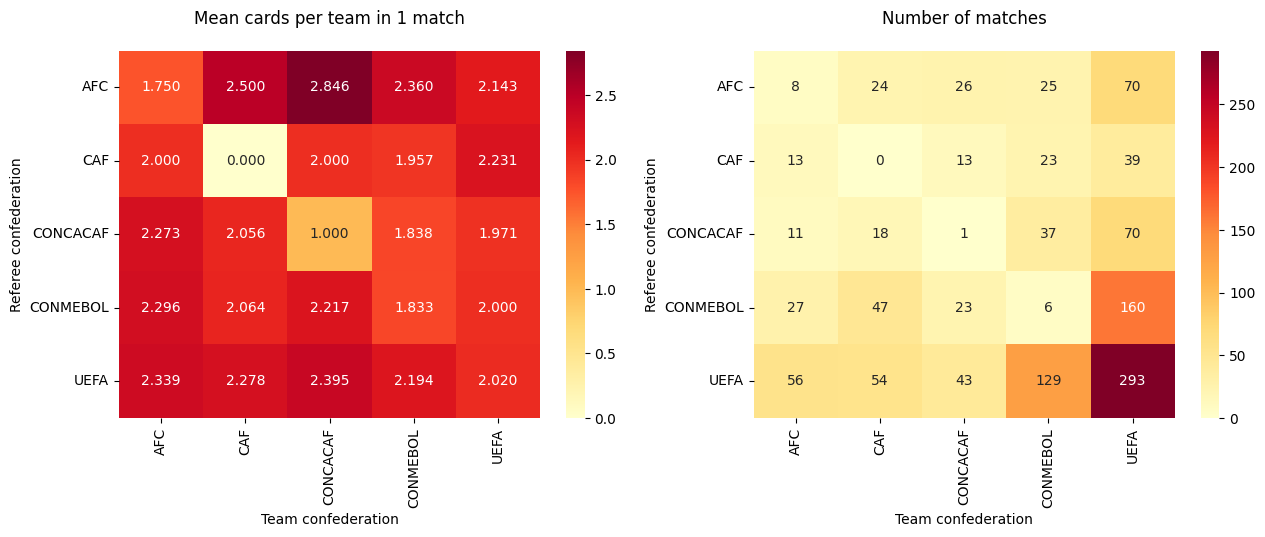

In [1003]:
# visualization 1: heatmap of number of cards given to each confederation per match 
# by ref from each confederation

# visualization 2: heatmap of number of matches played by each confederation 
# officiated by ref from each confederation

fig, ax = plt.subplots(1, 2, figsize = (13, 5.5))

sns.heatmap(df_ref_team_match[["AFC", "CAF", "CONCACAF", "CONMEBOL", "UEFA"]], 
            annot = True,
            cmap = 'YlOrRd',
            fmt=".3f",
            ax = ax[0])
sns.heatmap(df_match_count[["AFC", "CAF", "CONCACAF", "CONMEBOL", "UEFA"]], 
            annot = True,
            cmap = 'YlOrRd',
            fmt=".0f", 
            ax = ax[1])
ax[0].set_yticklabels(["AFC", "CAF", "CONCACAF", "CONMEBOL", "UEFA"], rotation = 0)
ax[1].set_yticklabels(["AFC", "CAF", "CONCACAF", "CONMEBOL", "UEFA"], rotation = 0)
ax[0].set_title("Mean cards per team in 1 match", y = 1.05)
ax[1].set_title("Number of matches", y = 1.05)
ax[0].set_xlabel("Team confederation")
ax[1].set_xlabel("Team confederation")
ax[0].set_ylabel("Referee confederation")
ax[1].set_ylabel("Referee confederation")

plt.tight_layout()
plt.savefig("../results/heatmap_ref_team.png")

In [1004]:
# load matches and referee dataset

df_matches = pd.read_csv("../data/processed/matches.csv")
df_ref = pd.read_csv("../data/processed/referee.csv")
df_matches = df_matches[["match_id", 'home_team_id',
       'home_team_confederation', 'away_team_confederation',
       'away_team_id']]
df_ref = df_ref[["match_id", "referee_id", "confederation_code"]]
df_matches = pd.merge(df_matches, df_ref, on = "match_id", how = "left")
df_matches

,match_id,home_team_id,home_team_confederation,away_team_confederation,away_team_id,referee_id,confederation_code
0,M-1970-01,T-46,CONCACAF,UEFA,T-72,R-440,UEFA
1,M-1970-02,T-84,CONMEBOL,UEFA,T-40,R-115,UEFA
2,M-1970-03,T-28,UEFA,UEFA,T-61,R-254,UEFA
3,M-1970-04,T-56,CONMEBOL,UEFA,T-10,R-392,UEFA
4,M-1970-05,T-06,UEFA,CONCACAF,T-27,R-358,UEFA
...,...,...,...,...,...,...,...
759,M-2022-60,T-28,UEFA,UEFA,T-30,R-386,CONMEBOL
760,M-2022-61,T-03,CONMEBOL,UEFA,T-18,R-327,UEFA
761,M-2022-62,T-30,UEFA,CAF,T-47,R-362,CONCACAF
762,M-2022-63,T-18,UEFA,CAF,T-47,R-013,AFC


In [1005]:
# reformat matches to team-match unit of observation

df_home = df_matches[["match_id", "home_team_id", "home_team_confederation", "referee_id", "confederation_code"]].rename(
    columns = {
        "home_team_id": "team_id",
        "home_team_confederation": "team_confederation",
        "confederation_code": "ref_confederation"
    }
)
df_away = df_matches[["match_id", "away_team_id", "away_team_confederation", "referee_id", "confederation_code"]].rename(
    columns = {
        "away_team_id": "team_id",
        "away_team_confederation": "team_confederation",
        "confederation_code": "ref_confederation"
    }
)
df_team_match = pd.concat((df_home, df_away))
basic_analysis(df_team_match)
df_team_match.head()

Data shape: (1528, 5)

Columns: 
Index(['match_id', 'team_id', 'team_confederation', 'referee_id',
       'ref_confederation'],
      dtype='object')

Misisng values: 
match_id              0
team_id               0
team_confederation    0
referee_id            0
ref_confederation     0
dtype: int64 



,match_id,team_id,team_confederation,referee_id,ref_confederation
0,M-1970-01,T-46,CONCACAF,R-440,UEFA
1,M-1970-02,T-84,CONMEBOL,R-115,UEFA
2,M-1970-03,T-28,UEFA,R-254,UEFA
3,M-1970-04,T-56,CONMEBOL,R-392,UEFA
4,M-1970-05,T-06,UEFA,R-358,UEFA


In [1006]:
# merge bookings data

df_merge = pd.merge(
    df_team_match, 
    df_team_match_booking.drop(columns = ["ref_confederation", "team_confederation"]), 
    on = ["match_id", "team_id"], 
    how = "left"
)
df_merge["yellow_card"] = df_merge["yellow_card"].fillna(0).astype(int)
basic_analysis(df_merge)
df_merge.head()

Data shape: (1528, 6)

Columns: 
Index(['match_id', 'team_id', 'team_confederation', 'referee_id',
       'ref_confederation', 'yellow_card'],
      dtype='object')

Misisng values: 
match_id              0
team_id               0
team_confederation    0
referee_id            0
ref_confederation     0
yellow_card           0
dtype: int64 



,match_id,team_id,team_confederation,referee_id,ref_confederation,yellow_card
0,M-1970-01,T-46,CONCACAF,R-440,UEFA,1
1,M-1970-02,T-84,CONMEBOL,R-115,UEFA,0
2,M-1970-03,T-28,UEFA,R-254,UEFA,0
3,M-1970-04,T-56,CONMEBOL,R-392,UEFA,0
4,M-1970-05,T-06,UEFA,R-358,UEFA,0


Numerical summary of numbers of yellow cards per team per match: 
count    1528.000000
mean        1.697644
std         1.406857
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         9.000000
Name: yellow_card, dtype: float64


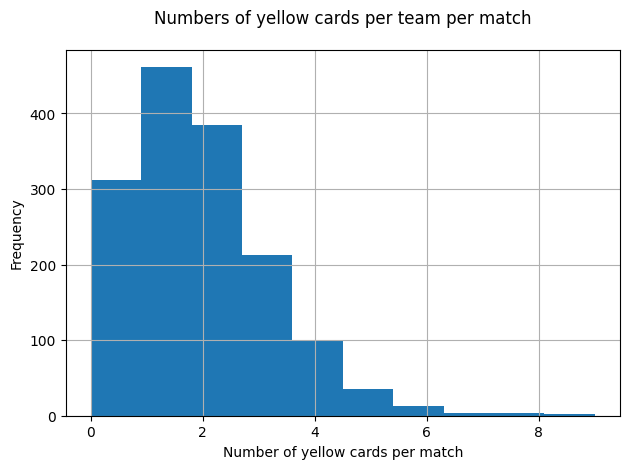

In [1007]:
# visualization: distribution of number of yellow cards each team receives per match 

print(f"Numerical summary of numbers of yellow cards per team per match: \n{df_merge["yellow_card"].describe()}")

df_merge["yellow_card"].hist()

plt.xlabel("Number of yellow cards per match")
plt.ylabel("Frequency")
plt.title("Numbers of yellow cards per team per match", y = 1.05)
plt.tight_layout()
plt.savefig("../results/yellow_per_team_match.png")

Because later tournaments have become larger in scale (more matches), they certainly have a higher number of cards. Therefore, we use a different metric - **average number of cards per match over time (for both teams in a match)** - to eliminate this scale bias.

In [1008]:
# number of yellow cards per tournament

df["match_date"] = pd.to_datetime(df["match_date"])
df["year"] = df["match_date"].dt.year
df_card_by_year = df[["year", "yellow_card"]].groupby("year").agg("sum").reset_index()
basic_analysis(df_card_by_year)
df_card_by_year

Data shape: (14, 2)

Columns: 
Index(['year', 'yellow_card'], dtype='object')

Misisng values: 
year           0
yellow_card    0
dtype: int64 



,year,yellow_card
0,1970,52
1,1974,84
2,1978,45
3,1982,99
4,1986,140
5,1990,171
6,1994,235
7,1998,255
8,2002,269
9,2006,345


In [1009]:
# number of matches per tournament

df_matches["year"] = df_matches["match_id"].str.extract(r"(\d{4})").astype(int)
print(f"Unique years: {df_matches["year"].unique()}")
df_year_match = df_matches.groupby("year").size().reset_index()
df_year_match.columns = ["year", "number_of_matches"]
basic_analysis(df_year_match)
df_year_match

Unique years: [1970 1974 1978 1982 1986 1990 1994 1998 2002 2006 2010 2014 2018 2022]
Data shape: (14, 2)

Columns: 
Index(['year', 'number_of_matches'], dtype='object')

Misisng values: 
year                 0
number_of_matches    0
dtype: int64 



,year,number_of_matches
0,1970,32
1,1974,38
2,1978,38
3,1982,52
4,1986,52
5,1990,52
6,1994,52
7,1998,64
8,2002,64
9,2006,64


In [1010]:
# average yellow cards per match

df_card_by_year = pd.merge(df_card_by_year, df_year_match, on = "year", how = "left")
df_card_by_year["yellow_card_per_match"] = df_card_by_year["yellow_card"] / df_card_by_year["number_of_matches"]
basic_analysis(df_card_by_year)
df_card_by_year

Data shape: (14, 4)

Columns: 
Index(['year', 'yellow_card', 'number_of_matches', 'yellow_card_per_match'], dtype='object')

Misisng values: 
year                     0
yellow_card              0
number_of_matches        0
yellow_card_per_match    0
dtype: int64 



,year,yellow_card,number_of_matches,yellow_card_per_match
0,1970,52,32,1.625000
1,1974,84,38,2.210526
2,1978,45,38,1.184211
3,1982,99,52,1.903846
4,1986,140,52,2.692308
5,1990,171,52,3.288462
6,1994,235,52,4.519231
7,1998,255,64,3.984375
8,2002,269,64,4.203125
9,2006,345,64,5.390625


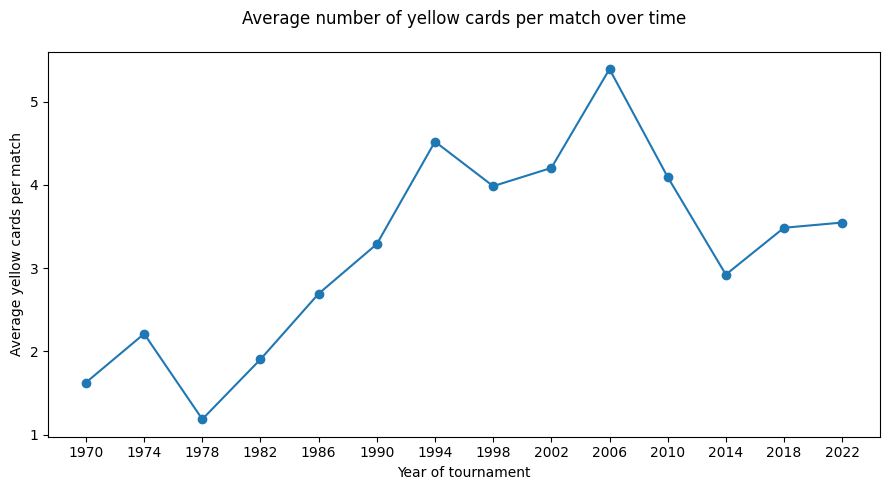

In [1011]:
# visualization: average number of yellow cards for both teams per match over time

plt.figure(figsize = (9, 5))
plt.plot(
    df_card_by_year["year"],
    df_card_by_year["yellow_card_per_match"],
    marker = "o"
)
plt.xticks(df_card_by_year["year"].values)
plt.xlabel("Year of tournament")
plt.ylabel("Average yellow cards per match")
plt.title("Average number of yellow cards per match over time", y = 1.05)
plt.tight_layout()
plt.savefig("../results/yellow_over_time.png")